# 01 — Systematic CTD Basis (cash-and-carry)

**Trade.** Long the basis = **buy the CTD cash bond** (financed in repo) and **sell CF-weighted futures** (= cash-and-carry = *long* the delivery optionality + carry). Short the basis = the reverse. We hold the front-contract CTD basis **continuously, rolling each quarter**, across TU/FV/TY/US, and mark to market daily.

**PnL** (long basis, per day):
`daily = cash_MTM(+) + futures_VM(short) + coupon_accrual(+) − repo_financing(−)`  ≈ `(face/100)·Δ(grossbasis = B − cf·F) + (coupon − repo)`.

**Financing.** SOFR GC proxy (`load_us_treasury_gc_fixing_pct`) **− CTD specialness**, ACT/360, on the cash leg's daily dirty value. Cash leg priced with QuantLib (FedInvest); futures + CTD/CF from `USTFuturesMDP`.

Built on the new `USTFutureBasis` Query object + `USTFutureBasisHandler` and the `BT.signals.ustf_basis.run_ustf_basis_backtest` runner.

In [1]:
import sys, os
REPO = r"C:\\Users\\chris\\clee\\ARBS"
if REPO not in sys.path:
    sys.path.insert(0, REPO)
import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pd.options.display.float_format = lambda x: f'{x:,.2f}'
from BT.signals.ustf_basis import UstfBasisConfig, run_ustf_basis_backtest, plot_pnl


In [2]:
# ---- config ----
START, END = datetime.date(2024, 6, 1), datetime.date(2026, 5, 31)
TENORS = ["TU", "FV", "TY", "US"]
SPECIALNESS_BPS = {"TU": 5.0, "FV": 8.0, "TY": 10.0, "US": 12.0}  # CTD repo specialness
BOND_FACE = 100_000_000.0   # cash face per tenor; futures CF-weighted to it
TX_COST_32NDS = 0.5         # round-trip basis cost per roll

cfg_long = UstfBasisConfig(tenors=TENORS, start=START, end=END, direction=+1,
                           bond_face=BOND_FACE, specialness_bps=SPECIALNESS_BPS,
                           tx_cost_32nds=TX_COST_32NDS, show_progress=True)
cfg_short = UstfBasisConfig(tenors=TENORS, start=START, end=END, direction=-1,
                            bond_face=BOND_FACE, specialness_bps=SPECIALNESS_BPS,
                            tx_cost_32nds=TX_COST_32NDS, show_progress=True)

In [3]:
res_long = run_ustf_basis_backtest(cfg_long)
res_long.combined.tail()


BACKTESTING...:   0%|          | 0/497 [00:00<?, ?step/s]


BACKTESTING...:   0%|          | 1/497 [00:00<07:31,  1.10step/s]


BACKTESTING...:   1%|          | 3/497 [00:01<02:30,  3.29step/s]


BACKTESTING...:   1%|          | 5/497 [00:01<01:35,  5.18step/s]


BACKTESTING...:   1%|▏         | 7/497 [00:01<01:13,  6.64step/s]

...


BACKTESTING...: 100%|█████████▉| 495/497 [04:10<00:01,  1.13step/s]


BACKTESTING...: 100%|█████████▉| 496/497 [04:10<00:00,  1.39step/s]


BACKTESTING...: 100%|██████████| 497/497 [04:10<00:00,  1.67step/s]


BACKTESTING...: 100%|██████████| 497/497 [04:10<00:00,  1.98step/s]

2026-05-22   3,587,744.17
2026-05-26   3,624,412.20
2026-05-27   3,234,257.23
2026-05-28   4,499,861.55
2026-05-29   3,078,150.64
dtype: float64

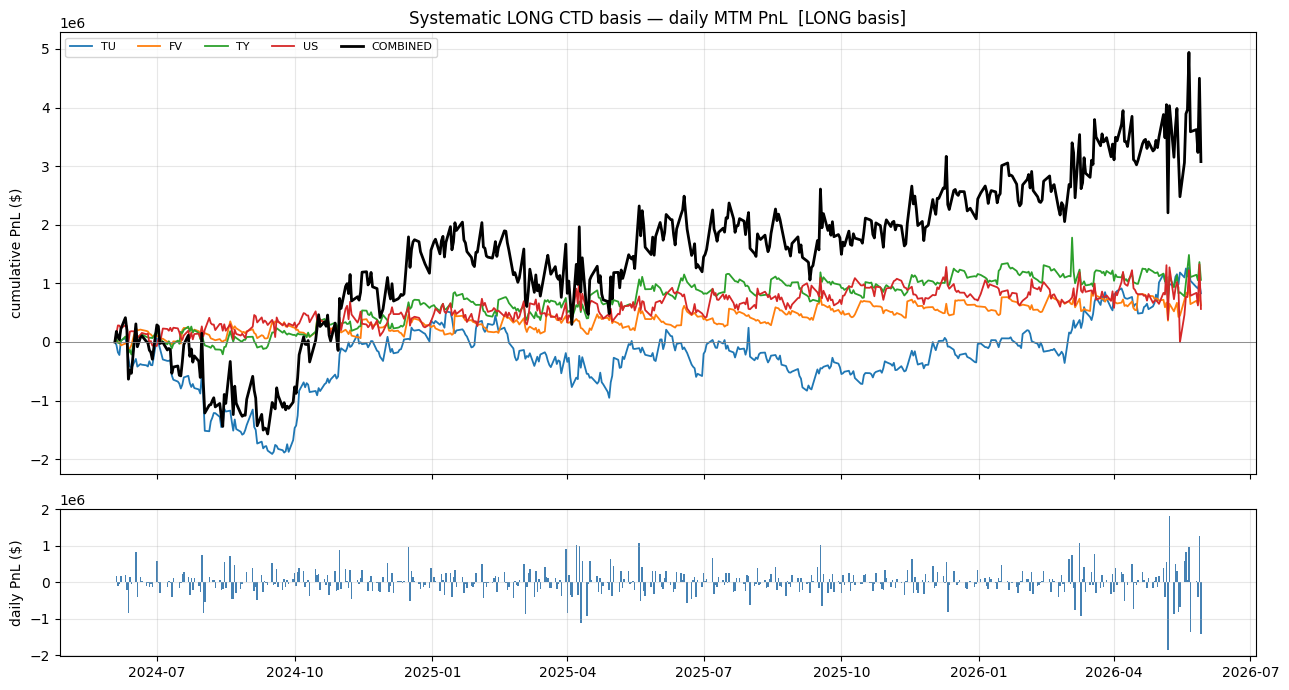

In [4]:
fig = plot_pnl(res_long, title='Systematic LONG CTD basis — daily MTM PnL')


BACKTESTING...:   0%|          | 0/497 [00:00<?, ?step/s]


BACKTESTING...:   0%|          | 2/497 [00:00<00:45, 10.95step/s]


BACKTESTING...:   1%|          | 4/497 [00:00<00:42, 11.54step/s]


BACKTESTING...:   1%|          | 6/497 [00:00<00:43, 11.35step/s]


BACKTESTING...:   2%|▏         | 8/497 [00:00<00:41, 11.84step/s]

...

C:\\Users\\chris\\clee\\ARBS\MDP\FixedRateBonds\FixedRateBondsMDP.py:990: RuntimeWarning: coroutine 'WSJFetcher.ust_intraday_timeseries.<locals>.run_fetch_all' was never awaited
  _logger.warning("Failed to fetch pricer for %s @ %s: %s", c, timestamp, e)



BACKTESTING...: 100%|█████████▉| 495/497 [04:26<00:02,  1.13s/step]


BACKTESTING...: 100%|█████████▉| 496/497 [04:26<00:00,  1.09step/s]


BACKTESTING...: 100%|██████████| 497/497 [04:27<00:00,  1.30step/s]


BACKTESTING...: 100%|██████████| 497/497 [04:27<00:00,  1.86step/s]

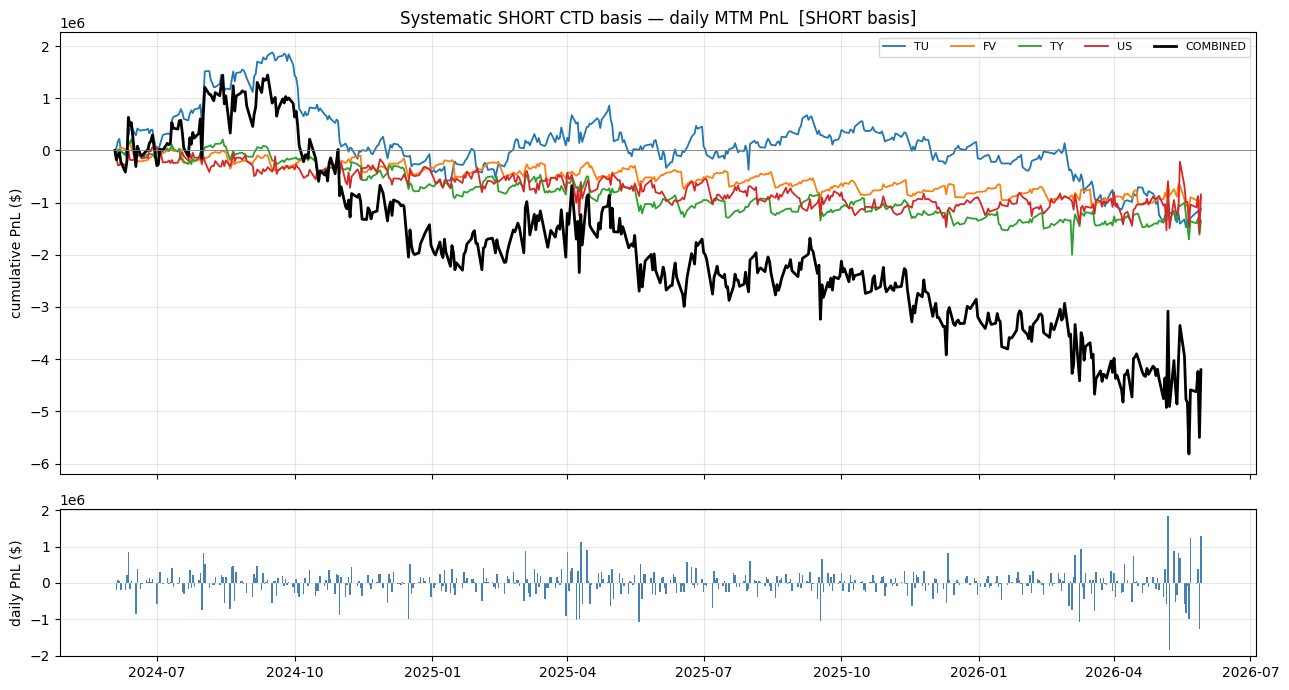

In [5]:
res_short = run_ustf_basis_backtest(cfg_short)
fig = plot_pnl(res_short, title='Systematic SHORT CTD basis — daily MTM PnL')

## PnL decomposition (long sleeve)
Total = price/convergence + carry (coupons − financing).

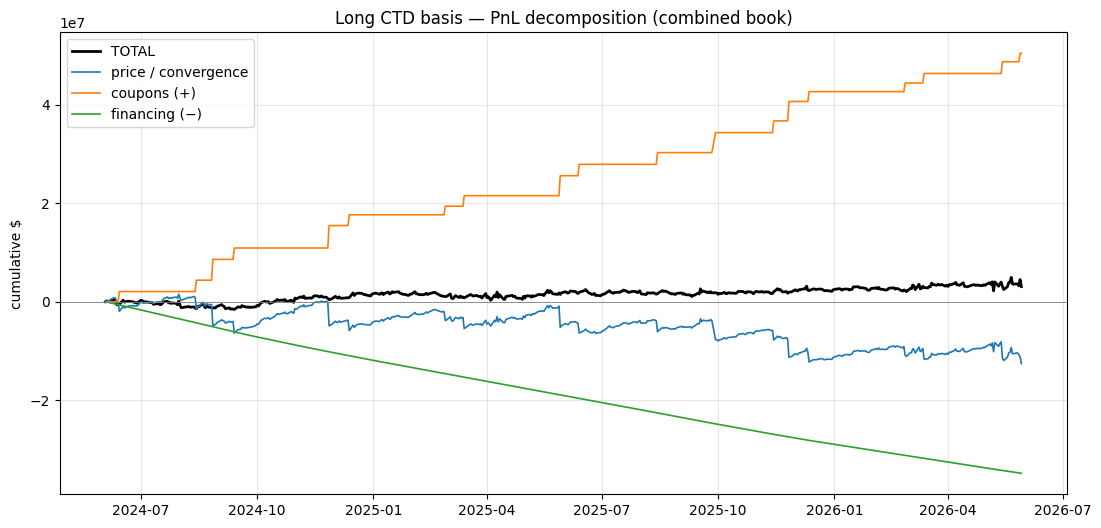

In [6]:
fin = pd.DataFrame({t: c['financing'] for t, c in res_long.components_by_tenor.items()}).ffill().fillna(0.0).sum(axis=1)
cpn = pd.DataFrame({t: c['coupons'] for t, c in res_long.components_by_tenor.items()}).ffill().fillna(0.0).sum(axis=1)
total = res_long.combined
price = (total - fin.reindex(total.index).ffill().fillna(0.0) - cpn.reindex(total.index).ffill().fillna(0.0))
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(total.index, total, label='TOTAL', color='black', lw=2)
ax.plot(price.index, price, label='price / convergence', lw=1.2)
ax.plot(cpn.index, cpn, label='coupons (+)', lw=1.2)
ax.plot(fin.index, fin, label='financing (−)', lw=1.2)
ax.axhline(0, color='grey', lw=0.6); ax.legend(); ax.grid(alpha=0.3)
ax.set_title('Long CTD basis — PnL decomposition (combined book)'); ax.set_ylabel('cumulative $')
plt.show()

## Summary

In [7]:
def summary(res, label):
    rows = []
    for t, s in res.mtm_by_tenor.items():
        dd = s.diff().fillna(0.0)
        sharpe = (dd.mean() / dd.std() * np.sqrt(252)) if dd.std() else float('nan')
        rows.append({'sleeve': label, 'tenor': t, 'total_pnl': s.iloc[-1] if len(s) else float('nan'),
                     'ann_sharpe': sharpe, 'days': len(s)})
    return pd.DataFrame(rows)
pd.concat([summary(res_long, 'long'), summary(res_short, 'short')], ignore_index=True)

,sleeve,tenor,total_pnl,ann_sharpe,days
0,long,TU,"831,449.92",0.21,497
1,long,FV,"623,392.96",0.24,497
2,long,TY,"1,059,645.18",0.31,497
3,long,US,"563,662.58",0.11,497
4,short,TU,"-1,112,699.92",-0.28,497
5,short,FV,"-904,642.96",-0.35,497
6,short,TY,"-1,340,895.18",-0.39,497
7,short,US,"-844,912.58",-0.17,497
